In [1]:
# ============================================================
# Cell 1: Imports
# ============================================================

from pathlib import Path
from time import perf_counter, perf_counter_ns, sleep

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pynq import Overlay, MMIO
from IPython.display import display

print("Current Jupyter directory:", Path.cwd())

Current Jupyter directory: /home/xilinx/jupyter_notebooks/project_2


In [2]:
# ============================================================
# Cell 2: Complete Configuration
# Verified configuration for design_2
# ============================================================

# ------------------------------------------------------------
# 1. Hardware files
# ------------------------------------------------------------

BITSTREAM_FILE = "design_2.bit"
HWH_FILE = "design_2.hwh"


# ------------------------------------------------------------
# 2. Bubble Sort HEX file
# ------------------------------------------------------------

# This is the original verified Bubble Sort program.
# It contains 31 static instructions.
BUBBLE_HEX_FILE = "sort32_fixed.hex"


# ------------------------------------------------------------
# 3. IP block names
# ------------------------------------------------------------

INSTR_BRAM_IP_CANDIDATES = [
    "axi_bram_ctrl_0",
    "instruction_bram",
    "ibram",
]

DATA_BRAM_IP_CANDIDATES = [
    "axi_bram_ctrl_1",
    "data_bram",
    "dbram",
]

GPIO_IP_CANDIDATES = [
    "axi_gpio_0",
    "gpio",
]


# ============================================================
# 4. CPU logical addresses
# ============================================================

# CPU accesses the sorting array starting here.
CPU_ARRAY_ADDRESS = 0x1000

# CPU writes the completion MAGIC_NUMBER here.
CPU_STATUS_ADDRESS = 0x2000


# ============================================================
# 5. VERIFIED Python Data BRAM MMIO mapping
# ============================================================

# IMPORTANT:
#
# These are NOT the same as the CPU logical addresses.
#
# Verified working mapping:
#
# CPU 0x1000  --->  Python MMIO offset 0x1000
# CPU 0x2000  --->  Python MMIO offset 0x0000
#
# Do not reverse these two values.

ARRAY_MMIO_OFFSET = 0x1000

STATUS_MMIO_OFFSET = 0x0000


# ============================================================
# 6. Array configuration
# ============================================================

ARRAY_LENGTH = 32

WORD_SIZE = 4

ARRAY_SIZE_BYTES = (
    ARRAY_LENGTH
    * WORD_SIZE
)


# ============================================================
# 7. Completion MAGIC_NUMBER
# ============================================================

MAGIC_NUMBER = 0xCAFEBABE


# ============================================================
# 8. AXI GPIO register offsets
# ============================================================

GPIO_DATA_OFFSET = 0x00

GPIO_TRI_OFFSET = 0x04


# ------------------------------------------------------------
# GPIO / CPU reset convention
# ------------------------------------------------------------
#
# Your hardware has a NOT gate:
#
# GPIO = 0
#      ↓
# NOT
#      ↓
# CPU reset = 1
#
# Therefore:
#
# GPIO 0 = hold CPU in reset
# GPIO 1 = release CPU and run
# ------------------------------------------------------------

CPU_RESET_VALUE = 0x00000000

CPU_RUN_VALUE = 0x00000001


# ============================================================
# 9. Benchmark groups
# ============================================================

ROUND_GROUPS = [
    100,
    1000,
    10000,
]


# Number of warm-up executions before measurement.
WARMUP_RUNS = 5


# Maximum time allowed for one CPU execution.
TIMEOUT_SECONDS = 2.0


# Polling interval.
#
# This is only used if your run function contains sleep()
# during status polling.
POLL_INTERVAL_SECONDS = 0.0001


# ============================================================
# 10. Random input configuration
# ============================================================

RANDOM_SEED = 20260804

INPUT_LOW = -1000

INPUT_HIGH = 1000


# ============================================================
# 11. Output CSV files
# ============================================================

RAW_CSV_FILE = (
    "riscv_31_instruction_raw_results.csv"
)

SUMMARY_CSV_FILE = (
    "riscv_31_instruction_summary.csv"
)

COMPARISON_CSV_FILE = (
    "riscv_31_instruction_comparison.csv"
)


# ============================================================
# 12. Output figures
# ============================================================

MEAN_FIGURE_FILE = (
    "mean_execution_time_comparison.png"
)

TOTAL_FIGURE_FILE = (
    "total_wall_time_comparison.png"
)

BOXPLOT_FIGURE_FILE = (
    "execution_time_boxplot.png"
)


# ============================================================
# 13. Print configuration
# ============================================================

print("=" * 68)

print(
    "RISC-V CONTROLLED BENCHMARK CONFIGURATION"
)

print("=" * 68)


print("\nHardware:")

print(
    f"  Bitstream : {BITSTREAM_FILE}"
)

print(
    f"  HWH       : {HWH_FILE}"
)

print(
    f"  Bubble HEX: {BUBBLE_HEX_FILE}"
)


print("\nCPU logical addresses:")

print(
    f"  Array address : "
    f"0x{CPU_ARRAY_ADDRESS:04X}"
)

print(
    f"  Status address: "
    f"0x{CPU_STATUS_ADDRESS:04X}"
)


print("\nPython Data BRAM MMIO offsets:")

print(
    f"  Array offset : "
    f"0x{ARRAY_MMIO_OFFSET:04X}"
)

print(
    f"  Status offset: "
    f"0x{STATUS_MMIO_OFFSET:04X}"
)


print("\nArray:")

print(
    f"  Number of values: "
    f"{ARRAY_LENGTH}"
)

print(
    f"  Size: "
    f"{ARRAY_SIZE_BYTES} bytes"
)


print("\nCompletion:")

print(
    f"  MAGIC_NUMBER: "
    f"0x{MAGIC_NUMBER:08X}"
)


print("\nGPIO:")

print(
    f"  Reset value: "
    f"0x{CPU_RESET_VALUE:08X}"
)

print(
    f"  Run value  : "
    f"0x{CPU_RUN_VALUE:08X}"
)


print("\nBenchmark:")

print(
    f"  Groups: {ROUND_GROUPS}"
)

print(
    f"  Warm-up runs: {WARMUP_RUNS}"
)

print(
    f"  Timeout: {TIMEOUT_SECONDS} seconds"
)


# ============================================================
# 14. Safety assertions
# ============================================================

assert (
    ARRAY_MMIO_OFFSET
    == 0x1000
), (
    "ARRAY_MMIO_OFFSET is incorrect."
)

assert (
    STATUS_MMIO_OFFSET
    == 0x0000
), (
    "STATUS_MMIO_OFFSET is incorrect."
)

assert (
    CPU_RESET_VALUE
    == 0
)

assert (
    CPU_RUN_VALUE
    == 1
)

assert (
    ARRAY_LENGTH
    == 32
)


print()
print("=" * 68)

print(
    "CONFIGURATION CHECK: PASS"
)

print("=" * 68)

RISC-V CONTROLLED BENCHMARK CONFIGURATION

Hardware:
  Bitstream : design_2.bit
  HWH       : design_2.hwh
  Bubble HEX: sort32_fixed.hex

CPU logical addresses:
  Array address : 0x1000
  Status address: 0x2000

Python Data BRAM MMIO offsets:
  Array offset : 0x1000
  Status offset: 0x0000

Array:
  Number of values: 32
  Size: 128 bytes

Completion:
  MAGIC_NUMBER: 0xCAFEBABE

GPIO:
  Reset value: 0x00000000
  Run value  : 0x00000001

Benchmark:
  Groups: [100, 1000, 10000]
  Warm-up runs: 5
  Timeout: 2.0 seconds

CONFIGURATION CHECK: PASS


In [3]:
# ============================================================
# Cell 3: Check required hardware files
# ============================================================

if not Path(BITSTREAM_FILE).exists():
    raise FileNotFoundError(
        f"Cannot find {BITSTREAM_FILE}. "
        f"Upload it to {Path.cwd()}."
    )

if not Path(HWH_FILE).exists():
    raise FileNotFoundError(
        f"Cannot find {HWH_FILE}. "
        "It must be generated together with design_2.bit."
    )

print("Hardware files found:")
print(f"  {BITSTREAM_FILE}: {Path(BITSTREAM_FILE).stat().st_size} bytes")
print(f"  {HWH_FILE}: {Path(HWH_FILE).stat().st_size} bytes")

Hardware files found:
  design_2.bit: 4045676 bytes
  design_2.hwh: 268260 bytes


In [4]:
# ============================================================
# Cell 4: Create safe 31-instruction arithmetic benchmark
# ============================================================

ARITHMETIC_HEX_FILE = "arithmetic_31_safe.hex"


ARITHMETIC_31_HEX = [

    # --------------------------------------------------------
    # x5 = 0x1000
    # --------------------------------------------------------

    "000012B7",     # 01: lui x5, 0x1

    # Wait for x5
    "00000013",     # 02: nop
    "00000013",     # 03: nop
    "00000013",     # 04: nop


    # --------------------------------------------------------
    # Read first three input values
    #
    # x6 = array[0]
    # x7 = array[1]
    # x9 = array[2]
    # --------------------------------------------------------

    "0002A303",     # 05: lw x6, 0(x5)
    "0042A383",     # 06: lw x7, 4(x5)
    "0082A483",     # 07: lw x9, 8(x5)

    # Wait for load results
    "00000013",     # 08: nop
    "00000013",     # 09: nop
    "00000013",     # 10: nop


    # --------------------------------------------------------
    # x8 = a + b
    # --------------------------------------------------------

    "00730433",     # 11: add x8, x6, x7

    "00000013",     # 12: nop
    "00000013",     # 13: nop
    "00000013",     # 14: nop


    # --------------------------------------------------------
    # x12 = (a + b) - c
    # --------------------------------------------------------

    "40940633",     # 15: sub x12, x8, x9

    "00000013",     # 16: nop
    "00000013",     # 17: nop
    "00000013",     # 18: nop


    # --------------------------------------------------------
    # x13 = ((a + b) - c) + a
    # --------------------------------------------------------

    "006606B3",     # 19: add x13, x12, x6

    "00000013",     # 20: nop
    "00000013",     # 21: nop
    "00000013",     # 22: nop


    # --------------------------------------------------------
    # Store result back to array[0]
    #
    # CPU address = 0x1000
    # --------------------------------------------------------

    "00D2A023",     # 23: sw x13, 0(x5)


    # --------------------------------------------------------
    # Padding
    # --------------------------------------------------------

    "00000013",     # 24: nop
    "00000013",     # 25: nop
    "00000013",     # 26: nop


    # --------------------------------------------------------
    # Write MAGIC_NUMBER = 0xCAFEBABE
    # CPU address = 0x2000
    # --------------------------------------------------------

    "00002537",     # 27: lui x10, 0x2

    "CAFEC5B7",     # 28: lui x11, 0xCAFEC

    "ABE58593",     # 29: addi x11, x11, -1346

    "00B52023",     # 30: sw x11, 0(x10)

    "0000006F",     # 31: jal x0, 0
]


# ============================================================
# Check
# ============================================================

assert len(ARITHMETIC_31_HEX) == 31


Path(ARITHMETIC_HEX_FILE).write_text(
    "\n".join(ARITHMETIC_31_HEX) + "\n",
    encoding="utf-8"
)


print("=" * 60)
print("Arithmetic 31 Benchmark")
print("=" * 60)

print("File:", ARITHMETIC_HEX_FILE)
print("Instruction count:", len(ARITHMETIC_31_HEX))
print("Program size:", len(ARITHMETIC_31_HEX) * 4, "bytes")

print()
print("Calculation:")
print("result = (array[0] + array[1] - array[2]) + array[0]")

print()
print("Result is written back to array[0].")
print("MAGIC_NUMBER = 0xCAFEBABE")

Arithmetic 31 Benchmark
File: arithmetic_31_safe.hex
Instruction count: 31
Program size: 124 bytes

Calculation:
result = (array[0] + array[1] - array[2]) + array[0]

Result is written back to array[0].
MAGIC_NUMBER = 0xCAFEBABE


In [5]:
# ============================================================
# Cell 5: Load design_2.bit
# ============================================================

print(f"Loading Overlay: {BITSTREAM_FILE}")

overlay = Overlay(BITSTREAM_FILE)

print("Overlay loaded successfully.")
print("\nAvailable IP blocks:")

for name, info in overlay.ip_dict.items():
    print(
        f"  {name:<45} "
        f"base=0x{info.get('phys_addr', 0):08X}, "
        f"range=0x{info.get('addr_range', 0):X}"
    )

print("\nAvailable memory blocks:")

memory_dict = getattr(overlay, "mem_dict", {})

if memory_dict:
    for name, info in memory_dict.items():
        print(
            f"  {name:<45} "
            f"base=0x{info.get('phys_addr', 0):08X}, "
            f"range=0x{info.get('addr_range', 0):X}"
        )
else:
    print("  No separate mem_dict entries.")

Loading Overlay: design_2.bit


Overlay loaded successfully.

Available IP blocks:
  axi_gpio_0                                    base=0x41200000, range=0x10000
  processing_system7_0                          base=0x00000000, range=0x0

Available memory blocks:
  axi_bram_ctrl_0                               base=0x40000000, range=0x2000
  axi_bram_ctrl_1                               base=0x42000000, range=0x2000
  PSDDR                                         base=0x00000000, range=0x0


In [6]:
# ============================================================
# Cell 6: Resolve BRAM and GPIO blocks
# ============================================================

def collect_addressable_blocks(overlay_object):
    blocks = {}

    for name, info in overlay_object.ip_dict.items():
        if "phys_addr" in info and "addr_range" in info:
            blocks[name] = {
                "source": "ip_dict",
                "phys_addr": info["phys_addr"],
                "addr_range": info["addr_range"],
            }

    for name, info in getattr(overlay_object, "mem_dict", {}).items():
        if "phys_addr" in info and "addr_range" in info:
            blocks[name] = {
                "source": "mem_dict",
                "phys_addr": info["phys_addr"],
                "addr_range": info["addr_range"],
            }

    return blocks


def resolve_block(blocks, exact_candidates, keyword_groups):
    # Exact match
    for candidate in exact_candidates:
        if candidate in blocks:
            return candidate

    # Hierarchical-name suffix match
    for candidate in exact_candidates:
        for name in blocks:
            if name.endswith("/" + candidate):
                return name

    # Keyword groups
    for keyword_group in keyword_groups:
        matches = []

        for name in blocks:
            lowered_name = name.lower()

            if all(
                keyword.lower() in lowered_name
                for keyword in keyword_group
            ):
                matches.append(name)

        if len(matches) == 1:
            return matches[0]

    return None


addressable_blocks = collect_addressable_blocks(overlay)

print("All addressable blocks:")

for name, info in addressable_blocks.items():
    print(
        f"  {name:<45} "
        f"source={info['source']:<8} "
        f"base=0x{info['phys_addr']:08X}, "
        f"range=0x{info['addr_range']:X}"
    )


INSTR_BRAM_IP = resolve_block(
    addressable_blocks,
    INSTR_BRAM_IP_CANDIDATES,
    [
        ["axi_bram_ctrl_0"],
        ["bram", "ctrl", "0"],
        ["instruction", "bram"],
        ["ibram"],
    ],
)

DATA_BRAM_IP = resolve_block(
    addressable_blocks,
    DATA_BRAM_IP_CANDIDATES,
    [
        ["axi_bram_ctrl_1"],
        ["bram", "ctrl", "1"],
        ["data", "bram"],
        ["dbram"],
    ],
)

GPIO_IP = resolve_block(
    addressable_blocks,
    GPIO_IP_CANDIDATES,
    [
        ["axi_gpio_0"],
        ["gpio"],
    ],
)

print("\nResolved blocks:")
print("  Instruction BRAM:", INSTR_BRAM_IP)
print("  Data BRAM:       ", DATA_BRAM_IP)
print("  GPIO:            ", GPIO_IP)

missing = []

if INSTR_BRAM_IP is None:
    missing.append("Instruction BRAM")

if DATA_BRAM_IP is None:
    missing.append("Data BRAM")

if GPIO_IP is None:
    missing.append("GPIO")

if missing:
    raise RuntimeError(
        "Cannot find the following PS-accessible blocks: "
        f"{missing}.\n"
        "Check that design_2.bit and design_2.hwh are a matching pair "
        "and that both AXI BRAM controllers are assigned addresses in Vivado."
    )

All addressable blocks:
  axi_gpio_0                                    source=ip_dict  base=0x41200000, range=0x10000
  axi_bram_ctrl_0                               source=mem_dict base=0x40000000, range=0x2000
  axi_bram_ctrl_1                               source=mem_dict base=0x42000000, range=0x2000

Resolved blocks:
  Instruction BRAM: axi_bram_ctrl_0
  Data BRAM:        axi_bram_ctrl_1
  GPIO:             axi_gpio_0


In [7]:
# ============================================================
# Cell 7: Create MMIO objects and initialize GPIO
# ============================================================

instr_info = addressable_blocks[INSTR_BRAM_IP]
data_info = addressable_blocks[DATA_BRAM_IP]
gpio_info = addressable_blocks[GPIO_IP]

instr_bram = MMIO(
    instr_info["phys_addr"],
    instr_info["addr_range"],
)

data_bram = MMIO(
    data_info["phys_addr"],
    data_info["addr_range"],
)

gpio_mmio = MMIO(
    gpio_info["phys_addr"],
    gpio_info["addr_range"],
)

# AXI GPIO TRI: 0 means output
gpio_mmio.write(GPIO_TRI_OFFSET, 0x00000000)

# Hold CPU in reset
gpio_mmio.write(GPIO_DATA_OFFSET, CPU_RESET_VALUE)
sleep(0.001)

print("MMIO objects created successfully.")
print(f"GPIO data register: 0x{gpio_mmio.read(GPIO_DATA_OFFSET):08X}")

MMIO objects created successfully.
GPIO data register: 0x00000000


In [8]:
# ============================================================
# Cell 8: Load original 31-instruction Bubble Sort
#         and 31-instruction Arithmetic baseline
# ============================================================

from pathlib import Path

BUBBLE_HEX_FILE = "sort32_fixed.hex"


def read_hex_file(filename):
    path = Path(filename)

    if not path.exists():
        raise FileNotFoundError(
            f"Cannot find HEX file: {filename}"
        )

    instructions = []

    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):

            line = line.strip()

            if not line:
                continue

            line = line.split("#", 1)[0].strip()
            line = line.split("//", 1)[0].strip()

            if not line:
                continue

            if line.lower().startswith("0x"):
                line = line[2:]

            try:
                instruction = int(line, 16)

            except ValueError as error:
                raise ValueError(
                    f"Invalid HEX in {filename}, "
                    f"line {line_number}: {line}"
                ) from error

            instructions.append(instruction)

    return instructions


# ------------------------------------------------------------
# Bubble Sort: original, unchanged
# ------------------------------------------------------------

bubble_instructions = read_hex_file(
    BUBBLE_HEX_FILE
)

print("Bubble Sort:")
print(" File:", BUBBLE_HEX_FILE)
print(
    " Instructions:",
    len(bubble_instructions)
)
print(
    " Size:",
    len(bubble_instructions) * 4,
    "bytes"
)

if len(bubble_instructions) != 31:
    raise RuntimeError(
        f"Bubble Sort contains "
        f"{len(bubble_instructions)} instructions. "
        "Expected 31."
    )


# ------------------------------------------------------------
# Arithmetic baseline
# ------------------------------------------------------------

arithmetic_instructions = read_hex_file(
    ARITHMETIC_HEX_FILE
)

print()
print("Arithmetic:")
print(" File:", ARITHMETIC_HEX_FILE)
print(
    " Instructions:",
    len(arithmetic_instructions)
)
print(
    " Size:",
    len(arithmetic_instructions) * 4,
    "bytes"
)

if len(arithmetic_instructions) != 31:
    raise RuntimeError(
        f"Arithmetic contains "
        f"{len(arithmetic_instructions)} instructions. "
        "Expected 31."
    )


# ------------------------------------------------------------
# Controlled-variable check
# ------------------------------------------------------------

print()
print("=" * 60)
print("CONTROLLED PROGRAM CHECK")
print("=" * 60)

print(
    f"Bubble Sort : "
    f"{len(bubble_instructions)} instructions, "
    f"{len(bubble_instructions) * 4} bytes"
)

print(
    f"Arithmetic  : "
    f"{len(arithmetic_instructions)} instructions, "
    f"{len(arithmetic_instructions) * 4} bytes"
)

assert len(bubble_instructions) == 31
assert len(arithmetic_instructions) == 31

print()
print("PASS: Both programs contain exactly 31 instructions.")

Bubble Sort:
 File: sort32_fixed.hex
 Instructions: 31
 Size: 124 bytes

Arithmetic:
 File: arithmetic_31_safe.hex
 Instructions: 31
 Size: 124 bytes

CONTROLLED PROGRAM CHECK
Bubble Sort : 31 instructions, 124 bytes
Arithmetic  : 31 instructions, 124 bytes

PASS: Both programs contain exactly 31 instructions.


In [9]:
# ============================================================
# Cell 9: BRAM and signed-integer helpers
# ============================================================

def unsigned32(value):
    return int(value) & 0xFFFFFFFF


def signed32(value):
    value = int(value) & 0xFFFFFFFF
    return value - 0x100000000 if value & 0x80000000 else value


def rv32(value):
    return signed32(unsigned32(value))


def load_program_to_ibram(instructions, clear_words=256):
    gpio_mmio.write(GPIO_DATA_OFFSET, CPU_RESET_VALUE)
    sleep(0.00001)

    program_bytes = len(instructions) * WORD_SIZE

    if program_bytes > instr_info["addr_range"]:
        raise RuntimeError(
            f"Program needs {program_bytes} bytes, "
            f"but IBRAM range is {instr_info['addr_range']} bytes."
        )

    maximum_words = instr_info["addr_range"] // WORD_SIZE
    words_to_clear = min(clear_words, maximum_words)

    # Fill the beginning of IBRAM with NOPs
    for index in range(words_to_clear):
        instr_bram.write(index * WORD_SIZE, 0x00000013)

    # Write program
    for index, instruction in enumerate(instructions):
        instr_bram.write(
            index * WORD_SIZE,
            unsigned32(instruction),
        )

    # Read-back verification
    for index, expected in enumerate(instructions):
        offset = index * WORD_SIZE
        actual = instr_bram.read(offset) & 0xFFFFFFFF

        if actual != unsigned32(expected):
            raise RuntimeError(
                f"IBRAM verification failed at instruction {index}.\n"
                f"Offset:   0x{offset:04X}\n"
                f"Expected: 0x{expected:08X}\n"
                f"Actual:   0x{actual:08X}"
            )

    print(
        f"Program loaded: {len(instructions)} instructions, "
        f"{program_bytes} bytes."
    )


def write_input_array(values):
    if len(values) != ARRAY_LENGTH:
        raise ValueError(
            f"Expected {ARRAY_LENGTH} values, got {len(values)}."
        )

    for index, value in enumerate(values):
        data_bram.write(
            ARRAY_MMIO_OFFSET + index * WORD_SIZE,
            unsigned32(value),
        )


def read_output_array(length=ARRAY_LENGTH):
    return [
        signed32(
            data_bram.read(
                ARRAY_MMIO_OFFSET + index * WORD_SIZE
            )
        )
        for index in range(length)
    ]


def clear_magic_number():
    data_bram.write(STATUS_MMIO_OFFSET, 0)

    actual = data_bram.read(STATUS_MMIO_OFFSET) & 0xFFFFFFFF

    if actual != 0:
        raise RuntimeError(
            f"Failed to clear MAGIC_NUMBER: 0x{actual:08X}"
        )


def read_magic_number():
    return data_bram.read(STATUS_MMIO_OFFSET) & 0xFFFFFFFF

In [10]:
# ============================================================
# Cell 10: Output validation
# ============================================================


# ============================================================
# 1. Arithmetic expected-value calculation
# ============================================================

def calculate_expected_arithmetic(input_values):
    """
    Arithmetic program performs:

        result =
        (array[0] + array[1] - array[2]) + array[0]

    All operations follow RV32 32-bit signed behavior.
    """

    a = int(input_values[0])
    b = int(input_values[1])
    c = int(input_values[2])

    result = rv32(a + b)
    result = rv32(result - c)
    result = rv32(result + a)

    return result


# ============================================================
# 2. Read Arithmetic result
# ============================================================

def read_arithmetic_result():
    """
    Arithmetic program writes its result back to array[0].

    Verified mapping:

        CPU address 0x1000
            ->
        Python MMIO offset 0x1000
    """

    raw_value = data_bram.read(
        ARRAY_MMIO_OFFSET
    )

    return signed32(raw_value)


# ============================================================
# 3. Validate Arithmetic
# ============================================================

def validate_arithmetic(input_values):

    expected = calculate_expected_arithmetic(
        input_values
    )

    actual = read_arithmetic_result()

    if actual != expected:

        raise RuntimeError(
            "Arithmetic output verification failed.\n"
            f"a = {int(input_values[0])}\n"
            f"b = {int(input_values[1])}\n"
            f"c = {int(input_values[2])}\n"
            f"Expected = {expected}\n"
            f"Actual   = {actual}\n"
            f"Result MMIO offset = "
            f"0x{ARRAY_MMIO_OFFSET:04X}"
        )

    return True


# ============================================================
# 4. Validate Bubble Sort
# ============================================================

def validate_bubble(input_values):

    expected = sorted(
        int(value)
        for value in input_values
    )

    actual = read_output_array(
        ARRAY_LENGTH
    )

    if actual != expected:

        mismatch = next(
            (
                index
                for index,
                (expected_value, actual_value)
                in enumerate(
                    zip(expected, actual)
                )
                if expected_value != actual_value
            ),
            None
        )

        raise RuntimeError(
            "Bubble Sort output verification failed.\n"
            f"First mismatch index: {mismatch}\n"
            f"Expected: {expected}\n"
            f"Actual:   {actual}"
        )

    return True


# ============================================================
# 5. Configuration check
# ============================================================

print("=" * 60)
print("Validation Configuration")
print("=" * 60)

print(
    f"Arithmetic result MMIO offset: "
    f"0x{ARRAY_MMIO_OFFSET:04X}"
)

print(
    "Arithmetic formula:"
)

print(
    "(array[0] + array[1] - array[2]) + array[0]"
)

print()

print(
    f"Bubble Sort result length: "
    f"{ARRAY_LENGTH}"
)

print()

print(
    "validate_arithmetic() ready."
)

print(
    "validate_bubble() ready."
)

print()

print("VALIDATION FUNCTIONS: PASS")

Validation Configuration
Arithmetic result MMIO offset: 0x1000
Arithmetic formula:
(array[0] + array[1] - array[2]) + array[0]

Bubble Sort result length: 32

validate_arithmetic() ready.
validate_bubble() ready.

VALIDATION FUNCTIONS: PASS


In [11]:
# ============================================================
# Cell 10: Output validation
# ============================================================

def expected_arithmetic_results(input_values):

    a = rv32(input_values[0])
    b = rv32(input_values[1])
    c = rv32(input_values[2])
    d = rv32(input_values[3])

    x10 = rv32(a + b)
    x11 = rv32(c + d)
    x12 = rv32(a - c)
    x13 = rv32(b - d)

    x14 = rv32(x10 + x11)
    x15 = rv32(x12 + x13)

    x16 = rv32(x14 + x15)
    x17 = rv32(x14 - x15)

    x18 = 7

    x19 = rv32(x16 + x18)
    x20 = rv32(x17 - x18)

    x21 = rv32(x19 + x20)
    x22 = rv32(x19 - x20)

    x23 = rv32(x21 + x10)
    x24 = rv32(x22 + x11)

    x25 = rv32(x23 - x12)
    x26 = rv32(x24 + x13)

    # 31条版本只写前4个结果
    return [
        x19,
        x20,
        x21,
        x25
    ]


def read_arithmetic_results():

    # CPU logical:
    # 0x1040
    # 0x1044
    # 0x1048
    # 0x104C

    offsets = [
        0x40,
        0x44,
        0x48,
        0x4C
    ]

    return [
        signed32(
            data_bram.read(
                ARRAY_MMIO_OFFSET + offset
            )
        )
        for offset in offsets
    ]


def validate_arithmetic(input_values):

    expected = expected_arithmetic_results(
        input_values
    )

    actual = read_arithmetic_results()

    if actual != expected:

        raise RuntimeError(
            "Arithmetic output verification failed.\n"
            f"First four inputs: "
            f"{list(map(int, input_values[:4]))}\n"
            f"Expected: {expected}\n"
            f"Actual:   {actual}"
        )


def validate_bubble(input_values):

    expected = sorted(
        int(value)
        for value in input_values
    )

    actual = read_output_array(
        ARRAY_LENGTH
    )

    if actual != expected:

        mismatch = next(
            (
                index
                for index,
                (
                    expected_value,
                    actual_value
                )
                in enumerate(
                    zip(expected, actual)
                )
                if (
                    expected_value
                    != actual_value
                )
            ),
            None,
        )

        raise RuntimeError(
            "Bubble Sort output verification failed.\n"
            f"First mismatch index: {mismatch}\n"
            f"Expected: {expected}\n"
            f"Actual:   {actual}"
        )

In [12]:
# ============================================================
# Cell 12: Generate identical input datasets
# ============================================================

rng = np.random.default_rng(RANDOM_SEED)

input_sets = {
    number_of_runs: rng.integers(
        low=INPUT_LOW,
        high=INPUT_HIGH + 1,
        size=(number_of_runs, ARRAY_LENGTH),
        dtype=np.int32,
    )
    for number_of_runs in ROUND_GROUPS
}

for number_of_runs, input_values in input_sets.items():
    print(
        f"Generated {number_of_runs} arrays, "
        f"shape={input_values.shape}"
    )

Generated 100 arrays, shape=(100, 32)
Generated 1000 arrays, shape=(1000, 32)
Generated 10000 arrays, shape=(10000, 32)


In [13]:
# ============================================================
# FIX: define run_cpu_once()
# Run this cell BEFORE the Functional Test cell
# ============================================================

from time import perf_counter_ns, sleep


def run_cpu_once(
    input_values,
    timeout_seconds=TIMEOUT_SECONDS
):
    """
    Run the RISC-V CPU once.

    Timing starts immediately before releasing CPU reset
    and ends when MAGIC_NUMBER = 0xCAFEBABE is detected.
    """

    # --------------------------------------------------------
    # 1. Hold CPU in reset
    # --------------------------------------------------------

    gpio_mmio.write(
        GPIO_DATA_OFFSET,
        CPU_RESET_VALUE
    )

    sleep(0.00001)


    # --------------------------------------------------------
    # 2. Write input data
    # --------------------------------------------------------

    write_input_array(
        input_values
    )


    # --------------------------------------------------------
    # 3. Clear previous MAGIC_NUMBER
    # --------------------------------------------------------

    clear_magic_number()


    # --------------------------------------------------------
    # 4. Start timing
    # --------------------------------------------------------

    start_ns = perf_counter_ns()


    # --------------------------------------------------------
    # 5. Release CPU
    # --------------------------------------------------------

    gpio_mmio.write(
        GPIO_DATA_OFFSET,
        CPU_RUN_VALUE
    )


    # --------------------------------------------------------
    # 6. Timeout deadline
    # --------------------------------------------------------

    deadline_ns = (
        start_ns
        +
        int(
            timeout_seconds
            * 1_000_000_000
        )
    )


    # --------------------------------------------------------
    # 7. Poll MAGIC_NUMBER
    # --------------------------------------------------------

    while True:

        status = read_magic_number()

        if status == MAGIC_NUMBER:

            end_ns = perf_counter_ns()

            break


        if perf_counter_ns() >= deadline_ns:

            # Put CPU back into reset
            gpio_mmio.write(
                GPIO_DATA_OFFSET,
                CPU_RESET_VALUE
            )

            raise TimeoutError(
                f"CPU timed out after "
                f"{timeout_seconds} seconds.\n"
                f"Last status: "
                f"0x{status:08X}"
            )


    # --------------------------------------------------------
    # 8. Stop CPU
    # --------------------------------------------------------

    gpio_mmio.write(
        GPIO_DATA_OFFSET,
        CPU_RESET_VALUE
    )


    # --------------------------------------------------------
    # 9. Convert ns -> ms
    # --------------------------------------------------------

    elapsed_ms = (
        end_ns - start_ns
    ) / 1_000_000.0


    return elapsed_ms


print("run_cpu_once() defined successfully.")

print(
    "Function exists:",
    callable(run_cpu_once)
)

run_cpu_once() defined successfully.
Function exists: True


In [14]:
# ============================================================
# FINAL OVERRIDE CELL
# Put this IMMEDIATELY BEFORE the Functional Test cell
# ============================================================

from pathlib import Path


# ============================================================
# 1. Build a very simple 31-instruction arithmetic baseline
#
# Operation:
#
#   x = array[0]
#   x = x + 1
#   array[0] = x
#   write 0xCAFEBABE
#
# This deliberately inserts many NOPs to avoid pipeline hazards.
# ============================================================

ARITHMETIC_HEX_FILE = "arithmetic_31_safe.hex"

ARITHMETIC_31_HEX = [

    # x5 = 0x1000
    "000012B7",     # 01 lui x5, 0x1

    # wait for x5
    "00000013",     # 02 nop
    "00000013",     # 03 nop
    "00000013",     # 04 nop

    # x6 = array[0]
    "0002A303",     # 05 lw x6, 0(x5)

    # wait for load
    "00000013",     # 06 nop
    "00000013",     # 07 nop
    "00000013",     # 08 nop
    "00000013",     # 09 nop

    # x6 = x6 + 1
    "00130313",     # 10 addi x6, x6, 1

    # wait for ALU result
    "00000013",     # 11 nop
    "00000013",     # 12 nop
    "00000013",     # 13 nop
    "00000013",     # 14 nop

    # array[0] = x6
    "0062A023",     # 15 sw x6, 0(x5)

    # padding
    "00000013",     # 16
    "00000013",     # 17
    "00000013",     # 18
    "00000013",     # 19
    "00000013",     # 20
    "00000013",     # 21
    "00000013",     # 22
    "00000013",     # 23
    "00000013",     # 24
    "00000013",     # 25
    "00000013",     # 26

    # MAGIC_NUMBER
    "00002537",     # 27 lui  x10, 0x2
    "CAFEC5B7",     # 28 lui  x11, 0xCAFEC
    "ABE58593",     # 29 addi x11, x11, -1346
    "00B52023",     # 30 sw   x11, 0(x10)

    # stop
    "0000006F",     # 31 jal x0, 0
]


assert len(ARITHMETIC_31_HEX) == 31


# Save HEX
Path(ARITHMETIC_HEX_FILE).write_text(
    "\n".join(ARITHMETIC_31_HEX) + "\n",
    encoding="utf-8"
)


# Convert directly to integers.
# Do NOT depend on an old Cell 8.
arithmetic_instructions = [
    int(value, 16)
    for value in ARITHMETIC_31_HEX
]


# ============================================================
# 2. Make sure Bubble Sort is the original 31-instruction one
# ============================================================

BUBBLE_HEX_FILE = "sort32_fixed.hex"

bubble_instructions = read_hex_file(
    BUBBLE_HEX_FILE
)

if len(bubble_instructions) != 31:
    raise RuntimeError(
        f"Bubble Sort contains "
        f"{len(bubble_instructions)} instructions, expected 31."
    )


# ============================================================
# 3. NEW Arithmetic validator
# ============================================================

def validate_arithmetic(input_values):

    # Program performs:
    #
    # array[0] = array[0] + 1

    expected = rv32(
        int(input_values[0]) + 1
    )

    # Result is written back to array[0].
    actual_raw = data_bram.read(
        ARRAY_MMIO_OFFSET
    )

    actual = signed32(actual_raw)

    if actual != expected:

        raise RuntimeError(
            "NEW Arithmetic validation failed.\n"
            f"Input array[0] = {int(input_values[0])}\n"
            f"Expected       = {expected}\n"
            f"Actual         = {actual}\n"
            f"Array offset   = "
            f"0x{ARRAY_MMIO_OFFSET:04X}"
        )

    return True


# ============================================================
# 4. Bubble validator
# ============================================================

def validate_bubble(input_values):

    expected = sorted(
        int(value)
        for value in input_values
    )

    actual = read_output_array(
        ARRAY_LENGTH
    )

    if actual != expected:

        mismatch = next(
            (
                index
                for index,
                (expected_value, actual_value)
                in enumerate(zip(expected, actual))
                if expected_value != actual_value
            ),
            None
        )

        raise RuntimeError(
            "Bubble Sort validation failed.\n"
            f"First mismatch index: {mismatch}\n"
            f"Expected: {expected}\n"
            f"Actual:   {actual}"
        )

    return True


# ============================================================
# 5. IMPORTANT:
# Rebuild PROGRAMS so it uses the NEW function objects
# ============================================================

PROGRAMS = {

    "Bubble Sort 31": {
        "instructions": bubble_instructions,
        "validator": validate_bubble,
    },

    "Arithmetic 31": {
        "instructions": arithmetic_instructions,
        "validator": validate_arithmetic,
    },
}


# ============================================================
# 6. Sanity checks
# ============================================================

print("=" * 65)
print("FINAL OVERRIDE CHECK")
print("=" * 65)

print(
    "Bubble Sort instructions:",
    len(bubble_instructions)
)

print(
    "Arithmetic instructions:",
    len(arithmetic_instructions)
)

print(
    "Array MMIO offset:",
    f"0x{ARRAY_MMIO_OFFSET:04X}"
)

print(
    "Status MMIO offset:",
    f"0x{STATUS_MMIO_OFFSET:04X}"
)

print()

print(
    "Arithmetic validator function:",
    validate_arithmetic.__name__
)

print(
    "Arithmetic validator code names:",
    validate_arithmetic.__code__.co_names
)


assert len(bubble_instructions) == 31
assert len(arithmetic_instructions) == 31

assert ARRAY_MMIO_OFFSET == 0x1000
assert STATUS_MMIO_OFFSET == 0x0000


# This MUST NOT exist in the new validator.
assert (
    "read_arithmetic_results"
    not in validate_arithmetic.__code__.co_names
)


print()
print("PASS: New Arithmetic program and validator are active.")
print()
print(
    "Expected for current test input:"
)

print(
    f"{int(input_sets[100][0][0])} + 1 = "
    f"{rv32(int(input_sets[100][0][0]) + 1)}"
)

FINAL OVERRIDE CHECK
Bubble Sort instructions: 31
Arithmetic instructions: 31
Array MMIO offset: 0x1000
Status MMIO offset: 0x0000

Arithmetic validator function: validate_arithmetic
Arithmetic validator code names: ('rv32', 'int', 'data_bram', 'read', 'ARRAY_MMIO_OFFSET', 'signed32', 'RuntimeError')

PASS: New Arithmetic program and validator are active.

Expected for current test input:
463 + 1 = 464


In [15]:
# ============================================================
# Cell 13: Functional test
# ============================================================

PROGRAMS = {
    "Bubble Sort 32": {
        "instructions": bubble_instructions,
        "validator": validate_bubble,
    },
    "Arithmetic 32": {
        "instructions": arithmetic_instructions,
        "validator": validate_arithmetic,
    },
}

test_input = input_sets[100][0].copy()

print("Functional-test input:")
print(test_input.tolist())

try:
    for program_name, config in PROGRAMS.items():
        print("\n" + "=" * 72)
        print("Testing:", program_name)
        print("=" * 72)

        load_program_to_ibram(config["instructions"])

        elapsed_ms = run_cpu_once(test_input)

        config["validator"](test_input)

        print("Result verification: PASS")
        print(f"Execution time: {elapsed_ms:.6f} ms")
        print(f"Magic number: 0x{read_magic_number():08X}")

finally:
    gpio_mmio.write(GPIO_DATA_OFFSET, CPU_RESET_VALUE)

print("\nAll functional tests passed.")

Functional-test input:
[463, -553, 94, -817, 298, 266, -234, -548, -525, 876, 606, 983, 460, 593, 662, -936, 711, -327, -123, -798, -213, 651, 62, -501, -919, -927, -344, -925, 168, 903, 673, 796]

Testing: Bubble Sort 32
Program loaded: 31 instructions, 124 bytes.
Result verification: PASS
Execution time: 0.411169 ms
Magic number: 0xCAFEBABE

Testing: Arithmetic 32
Program loaded: 31 instructions, 124 bytes.
Result verification: PASS
Execution time: 0.077384 ms
Magic number: 0xCAFEBABE

All functional tests passed.


In [16]:
# ============================================================
# Cell 14: Benchmark function
# ============================================================

def benchmark_program(
    program_name,
    instructions,
    validator,
    input_sets,
    warmup_runs=WARMUP_RUNS,
):
    print("\n" + "#" * 72)
    print("Loading:", program_name)
    print("#" * 72)

    load_start = perf_counter()
    load_program_to_ibram(instructions)
    program_load_ms = (perf_counter() - load_start) * 1000.0

    print(
        f"Program load and verification time: "
        f"{program_load_ms:.6f} ms"
    )

    if warmup_runs > 0:
        print(f"Running {warmup_runs} warm-up runs...")

        warmup_inputs = input_sets[ROUND_GROUPS[0]]

        for warmup_index in range(warmup_runs):
            run_cpu_once(
                warmup_inputs[
                    warmup_index % len(warmup_inputs)
                ]
            )

        print("Warm-up completed.")

    raw_records = []
    summary_records = []

    for number_of_runs in ROUND_GROUPS:
        print("\n" + "=" * 72)
        print(
            f"{program_name}: starting "
            f"{number_of_runs} measured runs"
        )
        print("=" * 72)

        benchmark_inputs = input_sets[number_of_runs]
        times_ms = []

        group_start = perf_counter()

        for run_index in range(number_of_runs):
            input_values = benchmark_inputs[run_index]
            elapsed_ms = run_cpu_once(input_values)

            times_ms.append(elapsed_ms)

            raw_records.append(
                {
                    "program": program_name,
                    "round_group": number_of_runs,
                    "run_index": run_index + 1,
                    "execution_ms": elapsed_ms,
                }
            )

            # Validate the first run in every group
            if run_index == 0:
                validator(input_values)

            progress_interval = max(
                1,
                number_of_runs // 10,
            )

            if (
                (run_index + 1) % progress_interval == 0
                or run_index + 1 == number_of_runs
            ):
                print(
                    f"{program_name}: "
                    f"{run_index + 1}/{number_of_runs}"
                )

        group_wall_seconds = perf_counter() - group_start
        values = np.asarray(times_ms, dtype=np.float64)

        summary = {
            "program": program_name,
            "instruction_count": len(instructions),
            "program_size_bytes": len(instructions) * WORD_SIZE,
            "rounds": number_of_runs,
            "mean_ms": float(np.mean(values)),
            "median_ms": float(np.median(values)),
            "std_ms": float(np.std(values, ddof=0)),
            "minimum_ms": float(np.min(values)),
            "maximum_ms": float(np.max(values)),
            "p95_ms": float(np.percentile(values, 95)),
            "group_wall_seconds": group_wall_seconds,
            "runs_per_second": number_of_runs / group_wall_seconds,
            "program_load_ms": program_load_ms,
        }

        summary_records.append(summary)

        print()
        print(f"Mean:       {summary['mean_ms']:.6f} ms")
        print(f"Median:     {summary['median_ms']:.6f} ms")
        print(f"Std:        {summary['std_ms']:.6f} ms")
        print(f"Minimum:    {summary['minimum_ms']:.6f} ms")
        print(f"Maximum:    {summary['maximum_ms']:.6f} ms")
        print(f"P95:        {summary['p95_ms']:.6f} ms")
        print(f"Wall time:  {summary['group_wall_seconds']:.3f} s")
        print(f"Throughput: {summary['runs_per_second']:.2f} runs/s")

    return raw_records, summary_records

In [17]:
# ============================================================
# Cell 15: Run all 22,200 measured executions
# ============================================================

all_raw_records = []
all_summary_records = []

overall_start = perf_counter()

try:
    for program_name, config in PROGRAMS.items():
        raw_records, summary_records = benchmark_program(
            program_name=program_name,
            instructions=config["instructions"],
            validator=config["validator"],
            input_sets=input_sets,
        )

        all_raw_records.extend(raw_records)
        all_summary_records.extend(summary_records)

finally:
    gpio_mmio.write(GPIO_DATA_OFFSET, CPU_RESET_VALUE)

overall_wall_seconds = perf_counter() - overall_start

expected_runs = len(PROGRAMS) * sum(ROUND_GROUPS)
actual_runs = len(all_raw_records)

print("\n" + "=" * 72)
print("All benchmark groups completed.")
print("=" * 72)
print("Successful measured runs:", actual_runs)
print("Expected measured runs:  ", expected_runs)
print(f"Overall wall time:        {overall_wall_seconds:.3f} seconds")

if actual_runs != expected_runs:
    raise RuntimeError(
        f"Expected {expected_runs} records, got {actual_runs}."
    )

print("\nFormal benchmark: PASS")


########################################################################
Loading: Bubble Sort 32
########################################################################
Program loaded: 31 instructions, 124 bytes.
Program load and verification time: 9.283230 ms
Running 5 warm-up runs...
Warm-up completed.

Bubble Sort 32: starting 100 measured runs
Bubble Sort 32: 10/100
Bubble Sort 32: 20/100
Bubble Sort 32: 30/100
Bubble Sort 32: 40/100
Bubble Sort 32: 50/100
Bubble Sort 32: 60/100
Bubble Sort 32: 70/100
Bubble Sort 32: 80/100
Bubble Sort 32: 90/100
Bubble Sort 32: 100/100

Mean:       0.386047 ms
Median:     0.382265 ms
Std:        0.008462 ms
Minimum:    0.377772 ms
Maximum:    0.421329 ms
P95:        0.400412 ms
Wall time:  0.152 s
Throughput: 658.31 runs/s

Bubble Sort 32: starting 1000 measured runs
Bubble Sort 32: 100/1000
Bubble Sort 32: 200/1000
Bubble Sort 32: 300/1000
Bubble Sort 32: 400/1000
Bubble Sort 32: 500/1000
Bubble Sort 32: 600/1000
Bubble Sort 32: 700/1000
Bubble

In [18]:
# ============================================================
# Cell 16: Create result tables and save CSV files
# ============================================================

raw_df = pd.DataFrame(all_raw_records)

summary_df = (
    pd.DataFrame(all_summary_records)
    .sort_values(["rounds", "program"])
    .reset_index(drop=True)
)

print("Summary table:")

display(
    summary_df[
        [
            "program",
            "instruction_count",
            "program_size_bytes",
            "rounds",
            "mean_ms",
            "median_ms",
            "std_ms",
            "minimum_ms",
            "maximum_ms",
            "p95_ms",
            "group_wall_seconds",
            "runs_per_second",
        ]
    ]
)

raw_df.to_csv(RAW_CSV_FILE, index=False)
summary_df.to_csv(SUMMARY_CSV_FILE, index=False)

comparison_rows = []

for number_of_runs in ROUND_GROUPS:
    group = (
        summary_df[summary_df["rounds"] == number_of_runs]
        .set_index("program")
    )

    bubble_mean = float(
        group.loc["Bubble Sort 32", "mean_ms"]
    )

    arithmetic_mean = float(
        group.loc["Arithmetic 32", "mean_ms"]
    )

    comparison_rows.append(
        {
            "rounds": number_of_runs,
            "bubble_mean_ms": bubble_mean,
            "arithmetic_mean_ms": arithmetic_mean,
            "difference_ms": bubble_mean - arithmetic_mean,
            "bubble_over_arithmetic_ratio": (
                bubble_mean / arithmetic_mean
            ),
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(COMPARISON_CSV_FILE, index=False)

print("\nComparison table:")
display(comparison_df)

print("\nSaved CSV files:")
print(" ", RAW_CSV_FILE)
print(" ", SUMMARY_CSV_FILE)
print(" ", COMPARISON_CSV_FILE)

Summary table:


,program,instruction_count,program_size_bytes,rounds,mean_ms,median_ms,std_ms,minimum_ms,maximum_ms,p95_ms,group_wall_seconds,runs_per_second
0,Arithmetic 32,31,124,100,0.054879,0.054289,0.005272,0.052843,0.106781,0.055359,0.112909,885.668872
1,Bubble Sort 32,31,124,100,0.386047,0.382265,0.008462,0.377772,0.421329,0.400412,0.151905,658.305658
2,Arithmetic 32,31,124,1000,0.055750,0.054492,0.006720,0.052474,0.182905,0.062218,1.166871,856.992710
3,Bubble Sort 32,31,124,1000,0.384976,0.381286,0.009106,0.377016,0.443520,0.401860,1.569213,637.262063
4,Arithmetic 32,31,124,10000,0.054739,0.054160,0.004629,0.051643,0.251581,0.055950,11.307237,884.389320
5,Bubble Sort 32,31,124,10000,0.388429,0.388677,0.022238,0.376154,1.997182,0.395311,15.104817,662.040481



Comparison table:


,rounds,bubble_mean_ms,arithmetic_mean_ms,difference_ms,bubble_over_arithmetic_ratio
0,100,0.386047,0.054879,0.331168,7.034547
1,1000,0.384976,0.055750,0.329226,6.905416
2,10000,0.388429,0.054739,0.333689,7.096004



Saved CSV files:
  riscv_31_instruction_raw_results.csv
  riscv_31_instruction_summary.csv
  riscv_31_instruction_comparison.csv


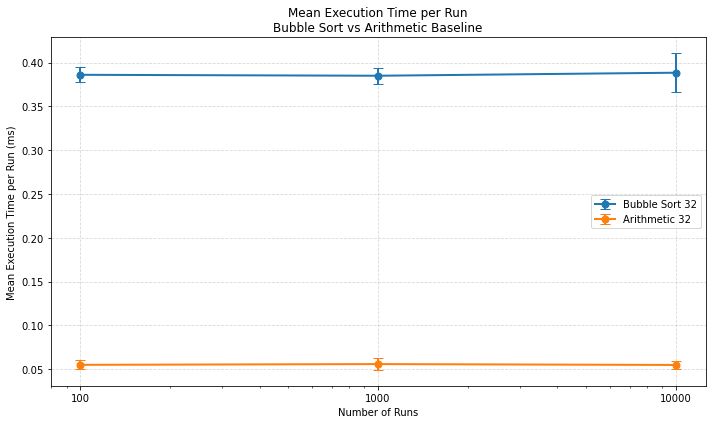

Saved: mean_execution_time_comparison.png


In [19]:
# ============================================================
# Cell 17: Plot 1 - Mean execution time
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

for program_name in PROGRAMS:
    program_data = (
        summary_df[summary_df["program"] == program_name]
        .sort_values("rounds")
    )

    ax.errorbar(
        program_data["rounds"],
        program_data["mean_ms"],
        yerr=program_data["std_ms"],
        marker="o",
        markersize=7,
        linewidth=2,
        capsize=5,
        label=program_name,
    )

ax.set_xscale("log")
ax.set_xticks(ROUND_GROUPS)
ax.set_xticklabels(
    [str(value) for value in ROUND_GROUPS]
)

ax.set_xlabel("Number of Runs")
ax.set_ylabel("Mean Execution Time per Run (ms)")
ax.set_title(
    "Mean Execution Time per Run\n"
    "Bubble Sort vs Arithmetic Baseline"
)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig(
    MEAN_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", MEAN_FIGURE_FILE)

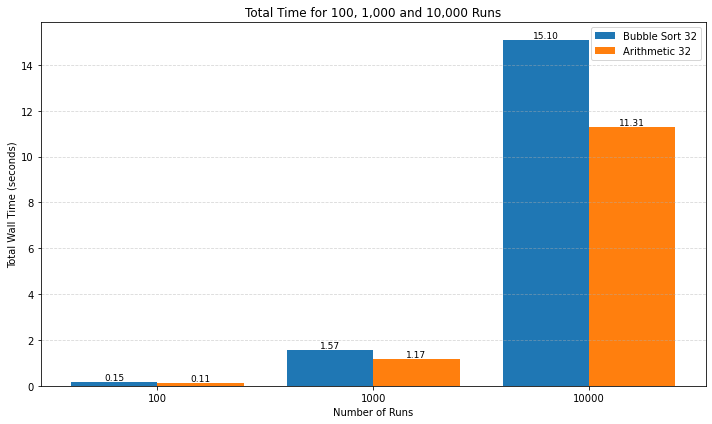

Saved: total_wall_time_comparison.png


In [20]:
# ============================================================
# Cell 18: Plot 2 - Total wall time
# ============================================================

program_names = list(PROGRAMS.keys())
x_positions = np.arange(len(ROUND_GROUPS))
bar_width = 0.8 / len(program_names)

fig, ax = plt.subplots(figsize=(10, 6))

for program_index, program_name in enumerate(program_names):
    program_data = (
        summary_df[summary_df["program"] == program_name]
        .set_index("rounds")
    )

    wall_times = [
        float(
            program_data.loc[
                number_of_runs,
                "group_wall_seconds",
            ]
        )
        for number_of_runs in ROUND_GROUPS
    ]

    offset = (
        program_index
        - (len(program_names) - 1) / 2
    ) * bar_width

    bars = ax.bar(
        x_positions + offset,
        wall_times,
        width=bar_width,
        label=program_name,
    )

    for bar, wall_time in zip(bars, wall_times):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{wall_time:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xticks(x_positions)
ax.set_xticklabels(
    [str(value) for value in ROUND_GROUPS]
)

ax.set_xlabel("Number of Runs")
ax.set_ylabel("Total Wall Time (seconds)")
ax.set_title("Total Time for 100, 1,000 and 10,000 Runs")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig(
    TOTAL_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", TOTAL_FIGURE_FILE)

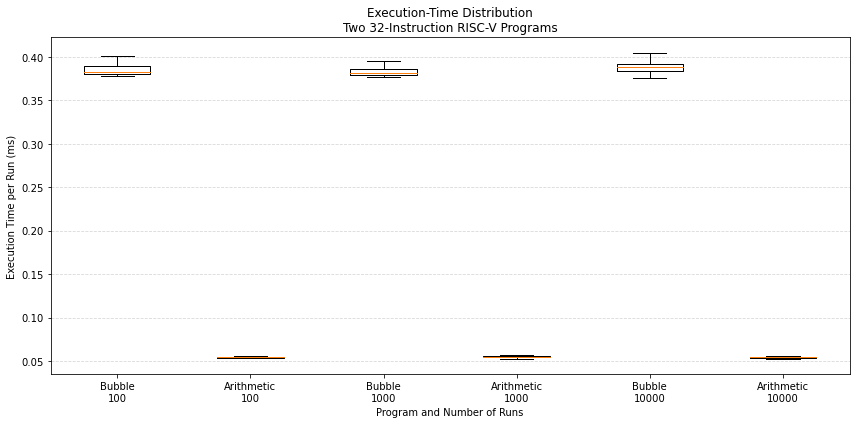

Saved: execution_time_boxplot.png


In [21]:
# ============================================================
# Cell 19: Plot 3 - Execution-time boxplot
# ============================================================

boxplot_data = []
boxplot_labels = []

for number_of_runs in ROUND_GROUPS:
    for program_name in PROGRAMS:
        selected = raw_df[
            (raw_df["program"] == program_name)
            & (raw_df["round_group"] == number_of_runs)
        ]["execution_ms"].dropna().to_numpy()

        if len(selected) == 0:
            continue

        boxplot_data.append(selected)

        short_name = (
            "Bubble"
            if "Bubble" in program_name
            else "Arithmetic"
        )

        boxplot_labels.append(
            f"{short_name}\n{number_of_runs}"
        )

fig, ax = plt.subplots(figsize=(12, 6))

# labels= is used for compatibility with older PYNQ Matplotlib versions.
ax.boxplot(
    boxplot_data,
    labels=boxplot_labels,
    showfliers=False,
)

ax.set_xlabel("Program and Number of Runs")
ax.set_ylabel("Execution Time per Run (ms)")
ax.set_title(
    "Execution-Time Distribution\n"
    "Two 32-Instruction RISC-V Programs"
)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(
    BOXPLOT_FIGURE_FILE,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", BOXPLOT_FIGURE_FILE)